# We Are All Average (Week 7)

This week we looked at how recommendation systems represent things as feature vectors.

Songs can be described through things like tempo and loudness. Films can be described through visual features. Recommender systems use these kinds of features to represent items as vectors so that similarity between them can be calculated.
Once everything is converted into numbers we can measure similarity between them.

That made me curious about what happens if we represent people in the same way.

Personality psychology already does something similar through the Big Five traits:

Extraversion  
Neuroticism  
Agreeableness  
Conscientiousness  
Openness

Each person can be described using five numbers, which basically places them somewhere in a five dimensional space.

The dataset I used contains responses from more than a million people who completed a Big Five personality questionnaire.

So instead of looking at individuals, I wanted to zoom out and look at the whole population.

Specifically I wanted to see:

• how personality traits are distributed  
• what the personality space looks like when projected into two dimensions  
• what happens if we force an algorithm to divide people into clusters

The question I am really asking is simple.

Do personality types actually appear in the data, or is it mostly just one big cloud of people who are all slightly different?

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

> **Note on Data:** The original dataset (1M+ responses, 397MB) exceeded the repository's file size limit, so it has been trimmed to 50,000 rows for reproducibility. The full dataset is available at:
> 
> [Big Five Personality Test — Kaggle](https://www.kaggle.com/datasets/tunguz/big-five-personality-test/data)

## Dataset

The dataset contains responses from a Big Five personality questionnaire.

Each row represents a person who completed the survey and each column represents one question.

The first confusing thing I ran into was that the file is 'tab separated instead of comma separated', so pandas needs `sep="\t"` when loading it.

Also this dataset is huge. Over a million responses. Not sure if my laptop would survive this

In [102]:
import pandas as pd

# create a trimmed dataset for reproducibility
df_full = pd.read_csv("data-final.csv", sep="\t")
df_full.head(50000).to_csv("data-sample.csv", index=False)

In [103]:
df = pd.read_csv("data-sample.csv")

In [104]:
# load dataset
df = pd.read_csv("data-final.csv", sep="\t")

# quick sanity check
print("Dataset shape:", df.shape)

df.head()

Dataset shape: (50000, 110)


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4,1,5,2,5,1,5,2,4,1,...,2016-03-03 02:01:01,768,1024,9,234,6,1,GB,51.5448,0.1991
1,3,5,3,4,3,3,2,5,1,5,...,2016-03-03 02:01:20,1360,768,12,179,11,1,MY,3.1698,101.706
2,2,3,4,4,3,2,1,3,2,5,...,2016-03-03 02:01:56,1366,768,3,186,7,1,GB,54.9119,-1.3833
3,2,2,2,3,4,2,2,4,1,4,...,2016-03-03 02:02:02,1920,1200,186,219,7,1,GB,51.75,-1.25
4,3,3,3,3,5,3,3,5,3,4,...,2016-03-03 02:02:57,1366,768,8,315,17,2,KE,1.0,38.0


Before cleaning anything I wanted to understand the structure of the dataset.

From the column names it looks like the questions follow a pattern:

EXT1, EXT2, EXT3  
AGR1, AGR2  
CSN1, CSN2  
EST1, EST2  
OPN1, OPN2

Each trait has 10 questions, so there should be **50 personality questions in total**.

The remaining columns seem to be metadata about the survey session such as screen size, time taken and approximate location.

Since I only care about the personality responses, I isolate the 50 question columns.

In [105]:
# show all column names
print(df.columns.tolist())

['EXT1', 'EXT2', 'EXT3', 'EXT4', 'EXT5', 'EXT6', 'EXT7', 'EXT8', 'EXT9', 'EXT10', 'EST1', 'EST2', 'EST3', 'EST4', 'EST5', 'EST6', 'EST7', 'EST8', 'EST9', 'EST10', 'AGR1', 'AGR2', 'AGR3', 'AGR4', 'AGR5', 'AGR6', 'AGR7', 'AGR8', 'AGR9', 'AGR10', 'CSN1', 'CSN2', 'CSN3', 'CSN4', 'CSN5', 'CSN6', 'CSN7', 'CSN8', 'CSN9', 'CSN10', 'OPN1', 'OPN2', 'OPN3', 'OPN4', 'OPN5', 'OPN6', 'OPN7', 'OPN8', 'OPN9', 'OPN10', 'EXT1_E', 'EXT2_E', 'EXT3_E', 'EXT4_E', 'EXT5_E', 'EXT6_E', 'EXT7_E', 'EXT8_E', 'EXT9_E', 'EXT10_E', 'EST1_E', 'EST2_E', 'EST3_E', 'EST4_E', 'EST5_E', 'EST6_E', 'EST7_E', 'EST8_E', 'EST9_E', 'EST10_E', 'AGR1_E', 'AGR2_E', 'AGR3_E', 'AGR4_E', 'AGR5_E', 'AGR6_E', 'AGR7_E', 'AGR8_E', 'AGR9_E', 'AGR10_E', 'CSN1_E', 'CSN2_E', 'CSN3_E', 'CSN4_E', 'CSN5_E', 'CSN6_E', 'CSN7_E', 'CSN8_E', 'CSN9_E', 'CSN10_E', 'OPN1_E', 'OPN2_E', 'OPN3_E', 'OPN4_E', 'OPN5_E', 'OPN6_E', 'OPN7_E', 'OPN8_E', 'OPN9_E', 'OPN10_E', 'dateload', 'screenw', 'screenh', 'introelapse', 'testelapse', 'endelapse', 'IPC', 'count

In [106]:
# select columns that look like personality questions
question_cols = [col for col in df.columns if len(col) <= 5 and col[-1].isdigit()]

df_questions = df[question_cols].copy()

print("Shape of question-only dataset:", df_questions.shape)

Shape of question-only dataset: (50000, 50)


Before computing trait scores I want to check whether there are any missing responses.

Since the dataset is so large, it’s possible that some participants skipped questions.

If there are incomplete rows, it will be safer to remove them so that each person has a full set of answers.

In [107]:
# check total missing values
print("Total missing values:", df_questions.isnull().sum().sum())

# remove incomplete responses
df_clean = df_questions.dropna()

print("Shape after removing incomplete rows:", df_clean.shape)

Total missing values: 0
Shape after removing incomplete rows: (50000, 50)


## Feature Representation

Each personality trait is measured using ten questions.

For example Extraversion is measured using EXT1 through EXT10.

To compute trait scores I simply average the responses belonging to each trait.

This leaves each person with five numbers:

Extraversion  
Neuroticism  
Agreeableness  
Conscientiousness  
Openness

At that point each person becomes a point in a five dimensional feature space.

This is essentially the same idea discussed in the lecture when representing items for recommendation systems. Instead of songs or films, each person is represented as a vector of numerical features. Once people are represented this way I can analyse similarity, structure and clustering in the same way I would analyze items in a recommendation system.

In [108]:
traits = pd.DataFrame()

# average the 10 questions belonging to each trait

traits["Extraversion"] = df_clean[
    ["EXT1","EXT2","EXT3","EXT4","EXT5",
     "EXT6","EXT7","EXT8","EXT9","EXT10"]
].mean(axis=1)

traits["Neuroticism"] = df_clean[
    ["EST1","EST2","EST3","EST4","EST5",
     "EST6","EST7","EST8","EST9","EST10"]
].mean(axis=1)

traits["Agreeableness"] = df_clean[
    ["AGR1","AGR2","AGR3","AGR4","AGR5",
     "AGR6","AGR7","AGR8","AGR9","AGR10"]
].mean(axis=1)

traits["Conscientiousness"] = df_clean[
    ["CSN1","CSN2","CSN3","CSN4","CSN5",
     "CSN6","CSN7","CSN8","CSN9","CSN10"]
].mean(axis=1)

traits["Openness"] = df_clean[
    ["OPN1","OPN2","OPN3","OPN4","OPN5",
     "OPN6","OPN7","OPN8","OPN9","OPN10"]
].mean(axis=1)

print(traits.shape)

traits.head()

(50000, 5)


,Extraversion,Neuroticism,Agreeableness,Conscientiousness,Openness
0,3.0,2.4,3.1,3.2,3.3
1,3.4,2.1,3.2,3.1,2.7
2,2.9,2.6,2.8,2.8,3.1
3,2.6,2.7,3.2,2.7,3.1
4,3.5,2.3,3.0,3.2,3.6


## Trial 1: Personality trait distributions

Before doing anything complex I wanted to see how each trait is distributed across the population.

Since the dataset contains over a million people, plotting the distributions should give a good overview of where most people sit on these scales.

In [109]:
traits.describe()

,Extraversion,Neuroticism,Agreeableness,Conscientiousness,Openness
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000
mean,3.044342,3.04784,3.160552,3.115804,3.253862
std,0.386910,0.66198,0.400428,0.432775,0.430191
min,0.000000,0.00000,0.000000,0.000000,0.000000
25%,2.800000,2.60000,3.000000,2.900000,3.000000
50%,3.000000,3.10000,3.200000,3.100000,3.300000
75%,3.300000,3.50000,3.400000,3.400000,3.500000
max,5.000000,5.00000,5.000000,5.000000,5.000000


In [110]:
traits_filtered = traits[(traits > 0).all(axis=1)]

print("Shape after removing zero values:", traits_filtered.shape)

traits_filtered.describe()

Shape after removing zero values: (49855, 5)


,Extraversion,Neuroticism,Agreeableness,Conscientiousness,Openness
count,49855.000000,49855.000000,49855.000000,49855.000000,49855.000000
mean,3.052851,3.056574,3.169532,3.124708,3.263177
std,0.353324,0.642731,0.364442,0.400484,0.394431
min,0.200000,0.100000,0.100000,0.100000,0.100000
25%,2.800000,2.600000,3.000000,2.900000,3.000000
50%,3.000000,3.100000,3.200000,3.100000,3.300000
75%,3.300000,3.500000,3.400000,3.400000,3.500000
max,5.000000,5.000000,5.000000,5.000000,5.000000


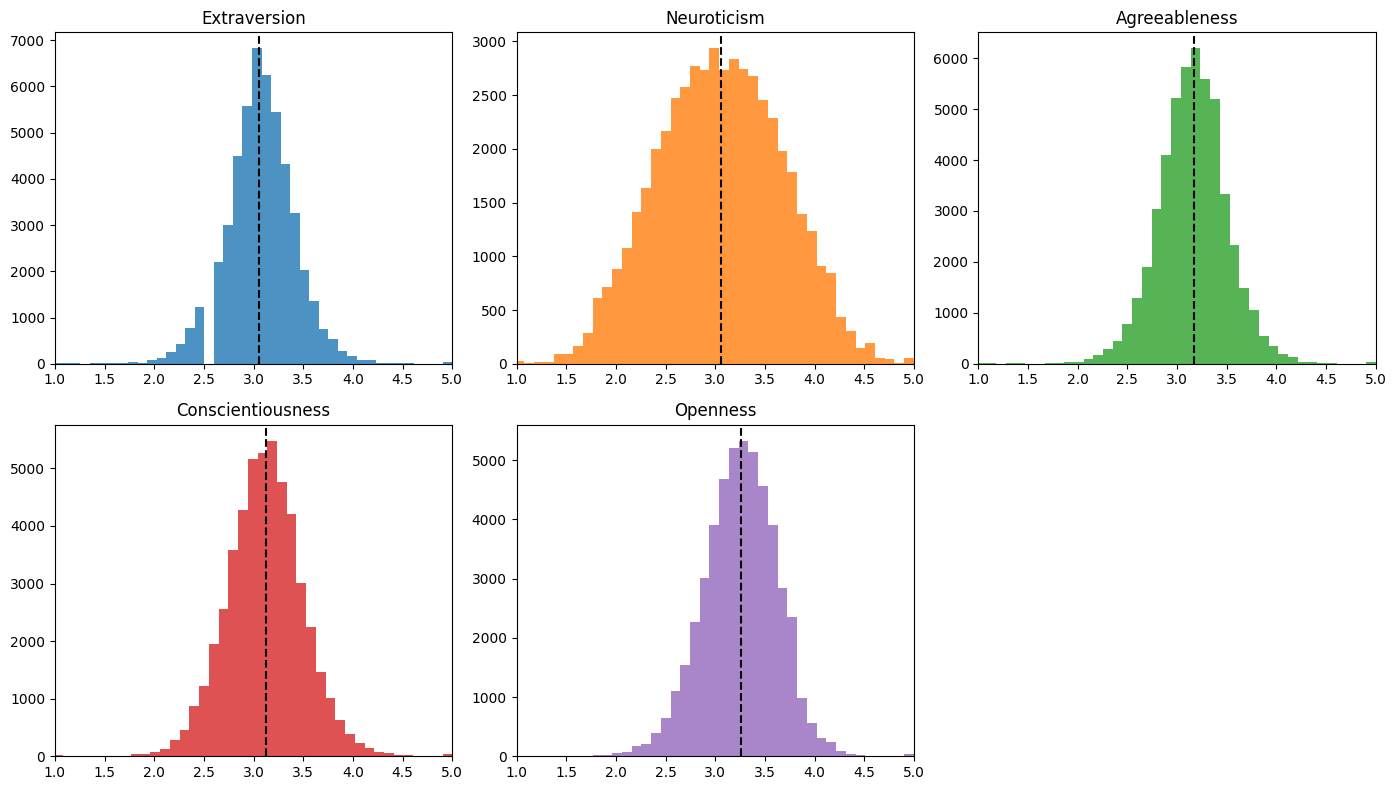

In [111]:
base_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, axes = plt.subplots(2,3, figsize=(14,8))

for i, trait in enumerate(traits_filtered.columns):

    ax = axes.flatten()[i]

    ax.hist(
        traits_filtered[trait],
        bins=50,
        color=base_colors[i % len(base_colors)],
        alpha=0.8
    )

    mean_val = traits_filtered[trait].mean()

    ax.axvline(mean_val, color="black", linestyle="--")

    ax.set_title(trait)
    ax.set_xlim(1,5)

axes.flatten()[5].axis("off")

plt.tight_layout()
plt.show()

The distributions are surprisingly similar across all five traits.

Each one forms a fairly tight bell-shaped curve centred very close to the middle of the scale.

Looking at the means confirms this:

Extraversion ≈ 3.03  
Neuroticism ≈ 3.03  
Agreeableness ≈ 3.16  
Conscientiousness ≈ 3.13  
Openness ≈ 3.27  

Since the questionnaire scale runs from 1 to 5, this means most people cluster very close to the midpoint.

The extreme ends of the scale do exist, but they are relatively rare compared to the large concentration of scores around the centre.

This is interesting because personality systems like MBTI often suggest that people fall into very distinct categories.  
But looking at these distributions, the population doesn't appear to split into separate groups. Instead it looks like most people sit somewhere near the middle of each trait, with gradual variation around that point.

## Trial 2: Mapping personality space with PCA

Looking at each trait individually is useful but every person actually has five scores.

That means each person is a point in a five dimensional space.

Since five dimensions cannot be visualised directly I reduce the space to two dimensions using PCA.

In [112]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
scaled_traits = scaler.fit_transform(traits_filtered)

pca = PCA(n_components=2)

components = pca.fit_transform(scaled_traits)

print("Variance explained:", sum(pca.explained_variance_ratio_))

Variance explained: 0.5585804304763808


The dataset is extremely large so plotting everything would produce an unreadable blob.

Instead I randomly sample fifty thousand people for visualisation.

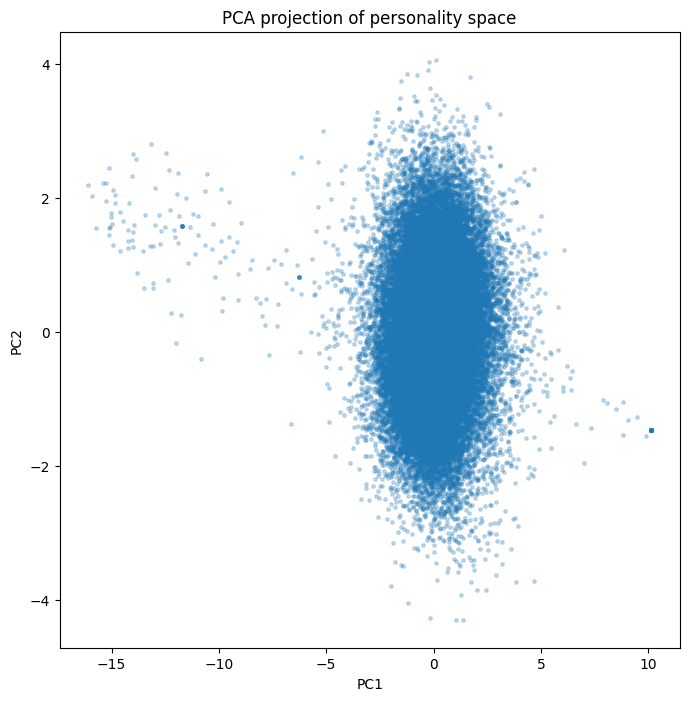

In [113]:
sample = traits_filtered.sample(n=min(50000, len(traits_filtered)), random_state=42)

sample_scaled = scaler.transform(sample)

sample_components = pca.transform(sample_scaled)

plt.figure(figsize=(8,8))

plt.scatter(
    sample_components[:,0],
    sample_components[:,1],
    s=6,
    alpha=0.25,
    color=base_colors[0]
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA projection of personality space")

plt.show()

The structure becomes clear in this plot.

Instead of splitting into separate clusters the data forms one dense cloud.

The center is extremely crowded which suggests most people sit close to the average combination of traits.

As you move away from the center the density gradually decreases.

## Trial 3: Forcing personality clusters

The PCA plot suggests that personality is continuous rather than divided into clear types.

But clustering algorithms do not know that.

If we ask an algorithm to divide the data into groups it will always produce clusters.

To test this I run K-Means with four clusters.

In [114]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

clusters = kmeans.fit_predict(scaled_traits)

traits_clustered = traits_filtered.copy()
traits_clustered["cluster"] = clusters

## Trial 4: Inspecting cluster profiles

If the clusters represent meaningful personality types we should see strong differences between their average trait scores.

In [115]:
cluster_means = traits_clustered.groupby("cluster").mean()

cluster_means

,Extraversion,Neuroticism,Agreeableness,Conscientiousness,Openness
cluster,,,,,
0,3.132763,2.451584,3.160213,3.081011,3.384670
1,2.807540,3.471805,3.109782,3.218875,3.370516
2,3.349914,3.488586,3.475224,3.394610,3.398949
3,2.954586,2.890983,2.946991,2.790708,2.832343


The differences between clusters are actually quite small.

Most trait values still sit very close to the middle of the scale.

This suggests the clusters are not dramatically different personality types. They are simply slightly different regions of the same continuous distribution.

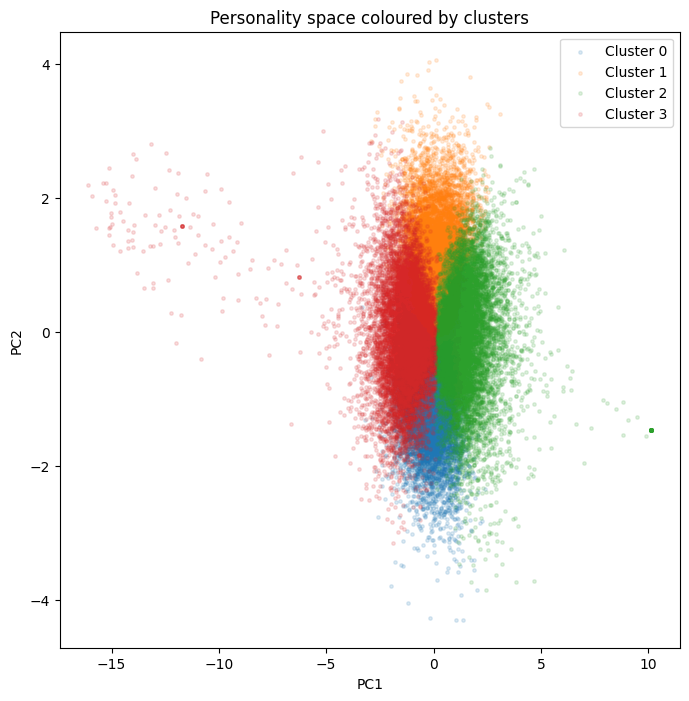

In [116]:
sample_idx = traits_filtered.sample(n=min(50000, len(traits_filtered)), random_state=42).index

sample_scaled = scaler.transform(traits_clustered.loc[sample_idx].drop(columns="cluster"))
sample_clusters = traits_clustered.loc[sample_idx]["cluster"]

sample_components = pca.transform(sample_scaled)

plt.figure(figsize=(8,8))

for i in range(4):

    mask = sample_clusters == i

    plt.scatter(
        sample_components[mask,0],
        sample_components[mask,1],
        s=6,
        alpha=0.15,
        color=base_colors[i % len(base_colors)],
        label=f"Cluster {i}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Personality space coloured by clusters")

plt.legend()

plt.show()

All four clusters occupy the same dense central region of the personality space.

The colours divide the cloud into geometric slices, but the points themselves blend smoothly across these boundaries.

This means the clusters are not naturally separated personality types. They are simply partitions created by the K-Means algorithm when it was forced to divide the data into groups.

In other words, most people still belong to the same continuous distribution. The cluster assignment mostly reflects where the algorithm decided to draw its boundaries rather than a meaningful personality category.

## Reflection

The thing that surprised me most was how boring the numbers actually are. Every trait mean is basically 3. On a scale of 1 to 5. That's it. I was expecting more variation honestly.

The PCA plot was the moment it clicked for me. A sample of fifty thousand people reduced to two dimensions and it's just... a cloud. No natural groups, no obvious structure. Just most people bunched in the middle with fewer and fewer people as you move outward.

The clustering step was interesting because the result looks convincing until you check the actual numbers. The cluster means are all within about half a point of each other. The colours make it look like four distinct personality types exist. They don't really.

I think that might be the main takeaway. Personality systems like MBTI feel precise because they give you a label. But the data doesn't really support the idea that people fall into discrete types. The variation is real, it's just continuous. The categories are something we impose on it, not something we find in it.

Statistically most of us really are just average. Which is either comforting or disappointing depending on how you look at it.

## LLM Disclaimer

I used LLMs occasionally while working with this dataset since it is extremely large. Got some help in debugging some pandas operations and checking that the filtering steps were correct.

I also used it to clarify parts of the PCA implementation and sampling process.